In [1]:
!pip install torch torchvision scikit-learn matplotlib seaborn -q

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import time

# 재현성 시드
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
config = {
    # 모델 구조
    "architecture": "CNN",
    "conv_layers": 2,
    "fc_layers": 2,
    "dropout_rate": 0.3,

    # 학습 설정
    "epochs": 10,
    "batch_size": 64,
    "learning_rate": 1e-3,
    "lr_step_size": 3,
    "lr_gamma": 0.5,
    "optimizer": "Adam",
    "weight_decay": 1e-4,

    # 데이터
    "dataset": "MNIST",
    "num_classes": 10,
}

print("📋 Hyperparameters:")
for k, v in config.items():
    print(f"  {k}: {v}")

📋 Hyperparameters:
  architecture: CNN
  conv_layers: 2
  fc_layers: 2
  dropout_rate: 0.3
  epochs: 10
  batch_size: 64
  learning_rate: 0.001
  lr_step_size: 3
  lr_gamma: 0.5
  optimizer: Adam
  weight_decay: 0.0001
  dataset: MNIST
  num_classes: 10


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=config["batch_size"], shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset):,} / Test: {len(test_dataset):,}")

Train: 60,000 / Test: 10,000


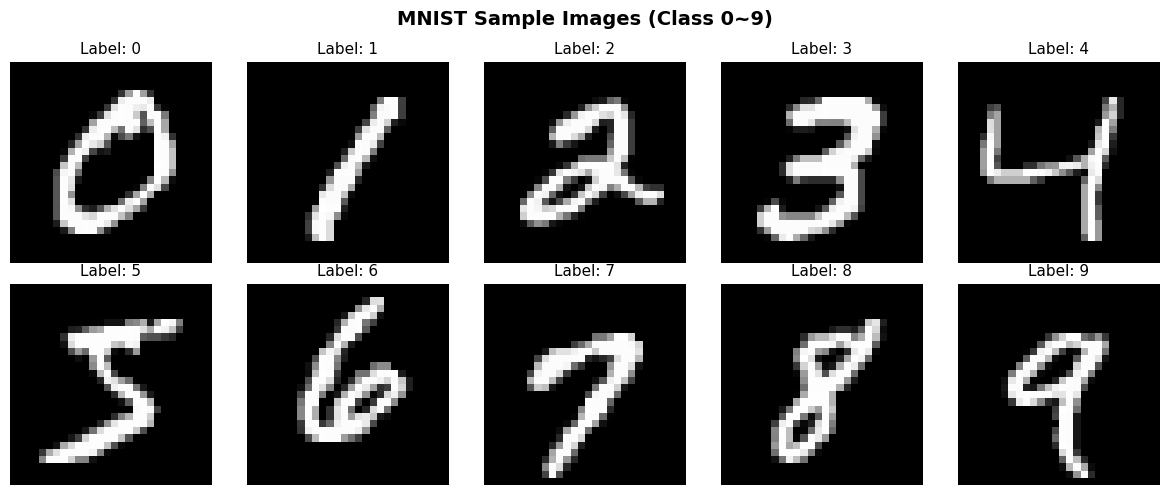

In [5]:
# 클래스별 샘플 이미지 수집
sample_images = {}
for img, label in train_dataset:
    label = int(label)
    if label not in sample_images:
        sample_images[label] = img.squeeze().numpy()
    if len(sample_images) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('MNIST Sample Images (Class 0~9)', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i], cmap='gray')
    ax.set_title(f'Label: {i}', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
class MnistCNN(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(MnistCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = MnistCNN(dropout_rate=config["dropout_rate"]).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())

print(f"Total params: {total_params:,}")

Total params: 824,650


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=config["lr_step_size"],
    gamma=config["lr_gamma"]
)

In [8]:
def compute_grad_norm(model):
    total_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total_norm += p.grad.data.norm(2).item() ** 2
    return total_norm ** 0.5


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    grad_norms = []

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        grad_norms.append(compute_grad_norm(model))
        optimizer.step()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        total_loss += loss.item()

    return total_loss / len(loader), correct / total, np.mean(grad_norms)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)

        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)
        total_loss += loss.item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return total_loss / len(loader), correct / total, \
           np.array(all_preds), np.array(all_labels), np.array(all_probs)

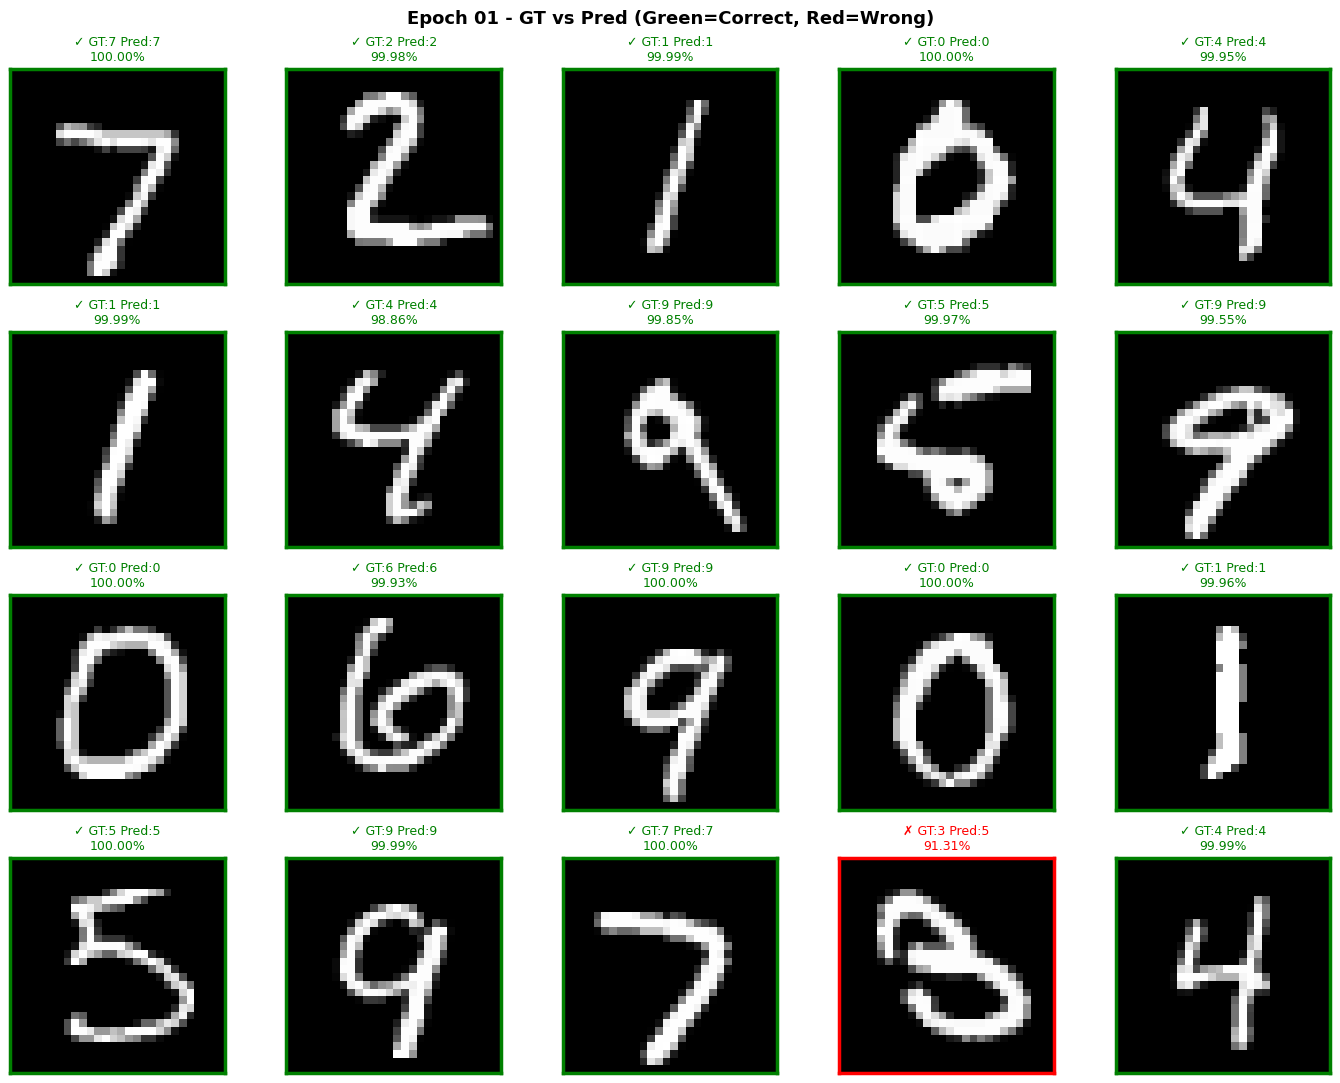

  Epoch 01/10 
  Train Loss: 0.1394 | Train Acc: 0.9563
  Val   Loss: 0.0609 | Val   Acc: 0.9796
  LR: 0.001000 | GradNorm: 1.7964 
  Epoch Time: 32.7s


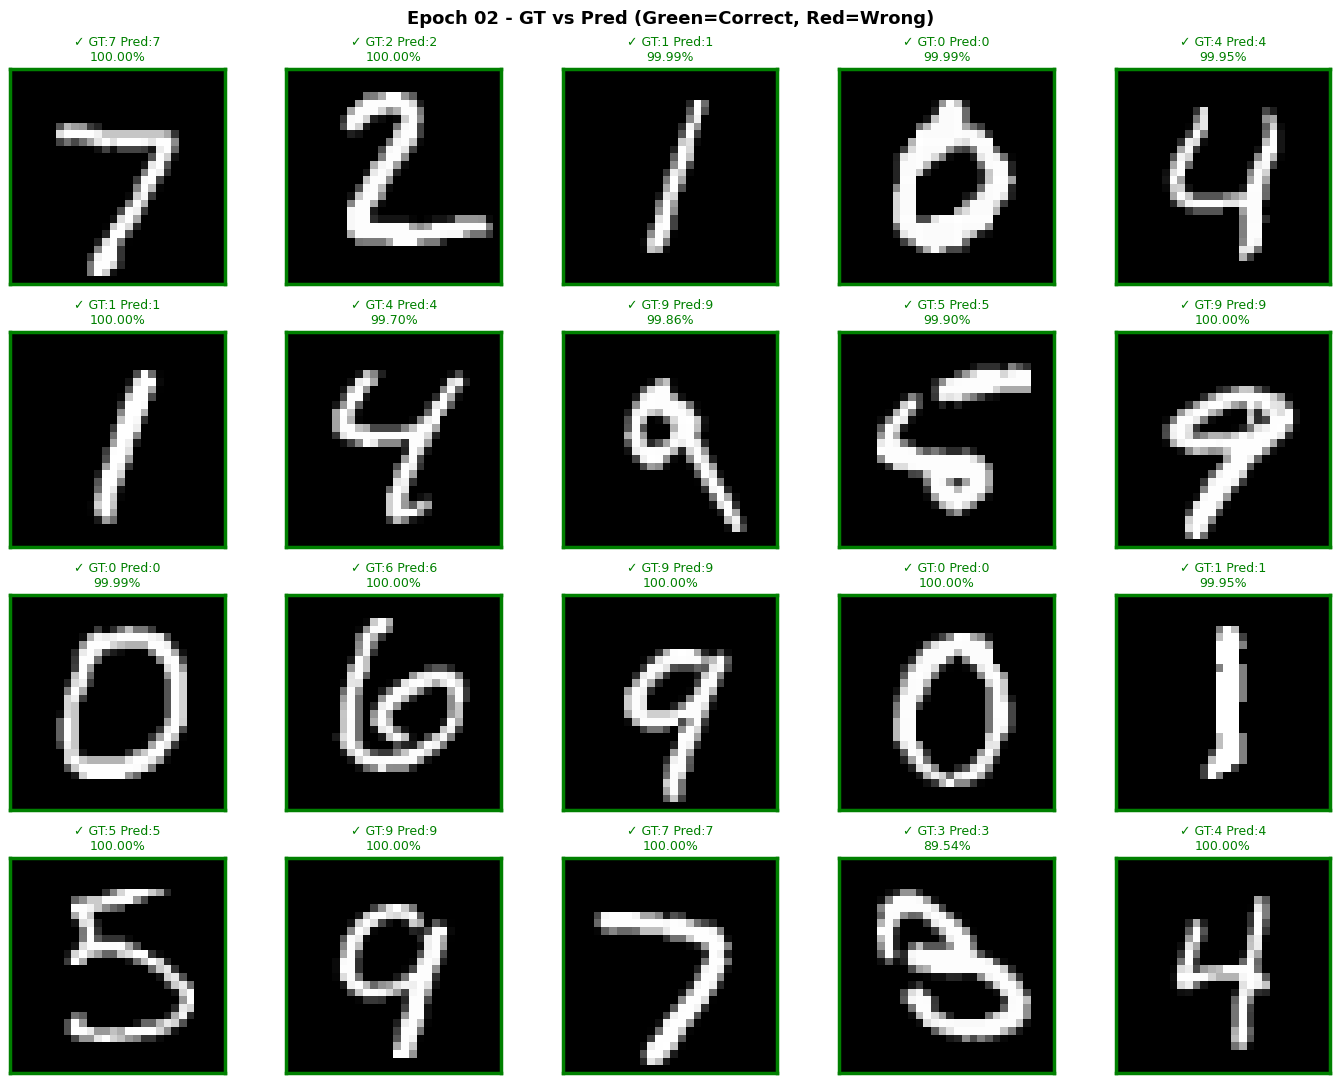

  Epoch 02/10 
  Train Loss: 0.0607 | Train Acc: 0.9809
  Val   Loss: 0.0388 | Val   Acc: 0.9878
  LR: 0.001000 | GradNorm: 1.2015 
  Epoch Time: 18.0s


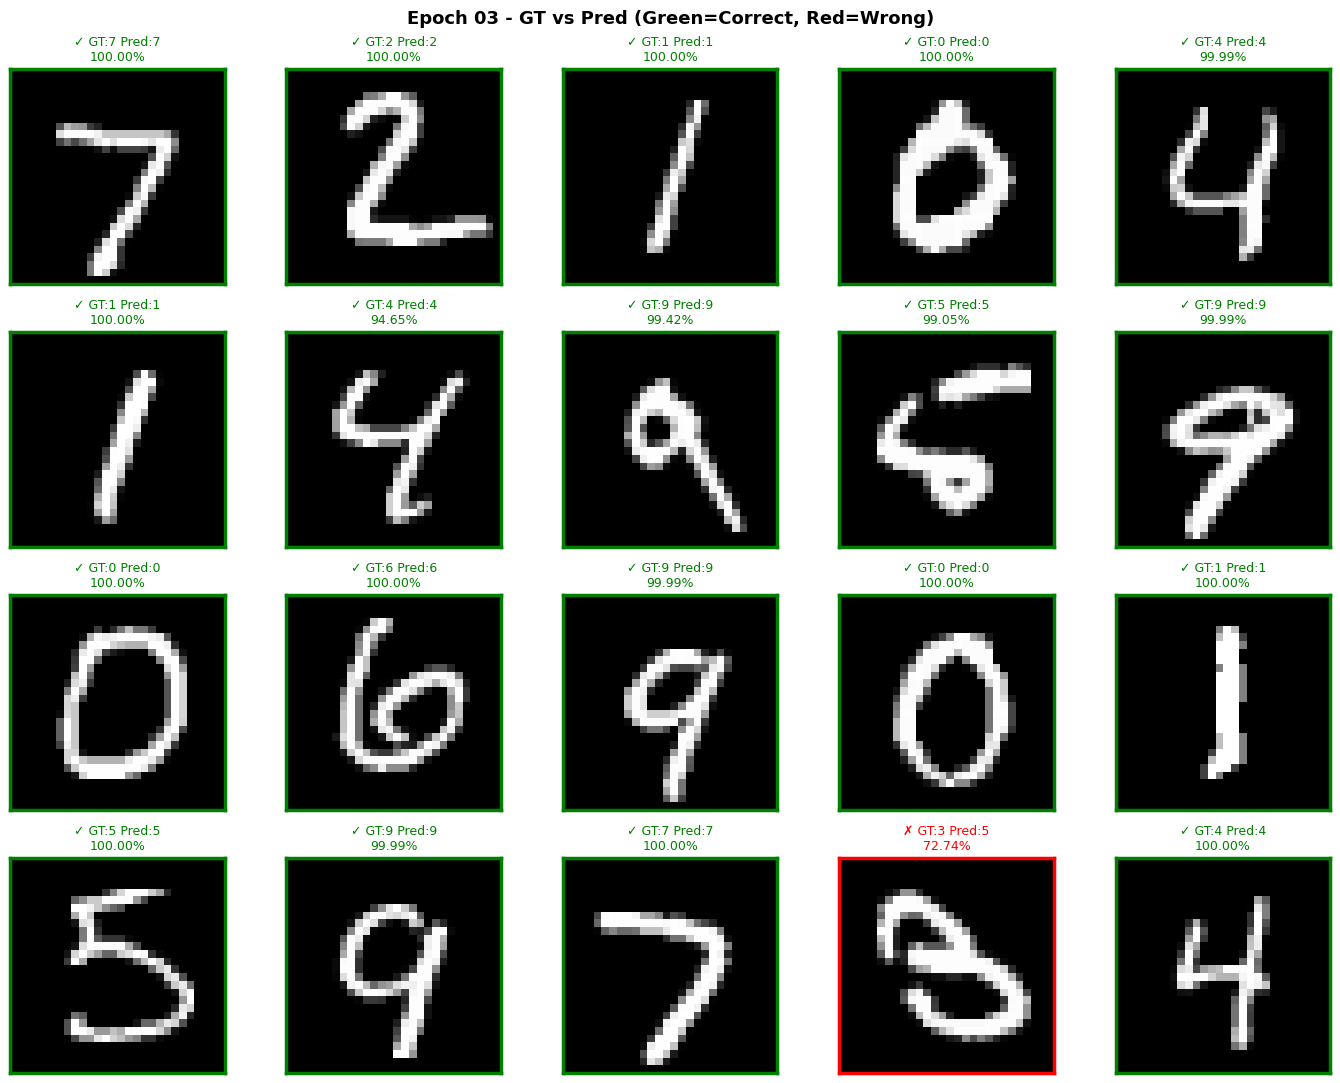

  Epoch 03/10 
  Train Loss: 0.0481 | Train Acc: 0.9850
  Val   Loss: 0.0288 | Val   Acc: 0.9905
  LR: 0.000500 | GradNorm: 1.0264 
  Epoch Time: 17.4s


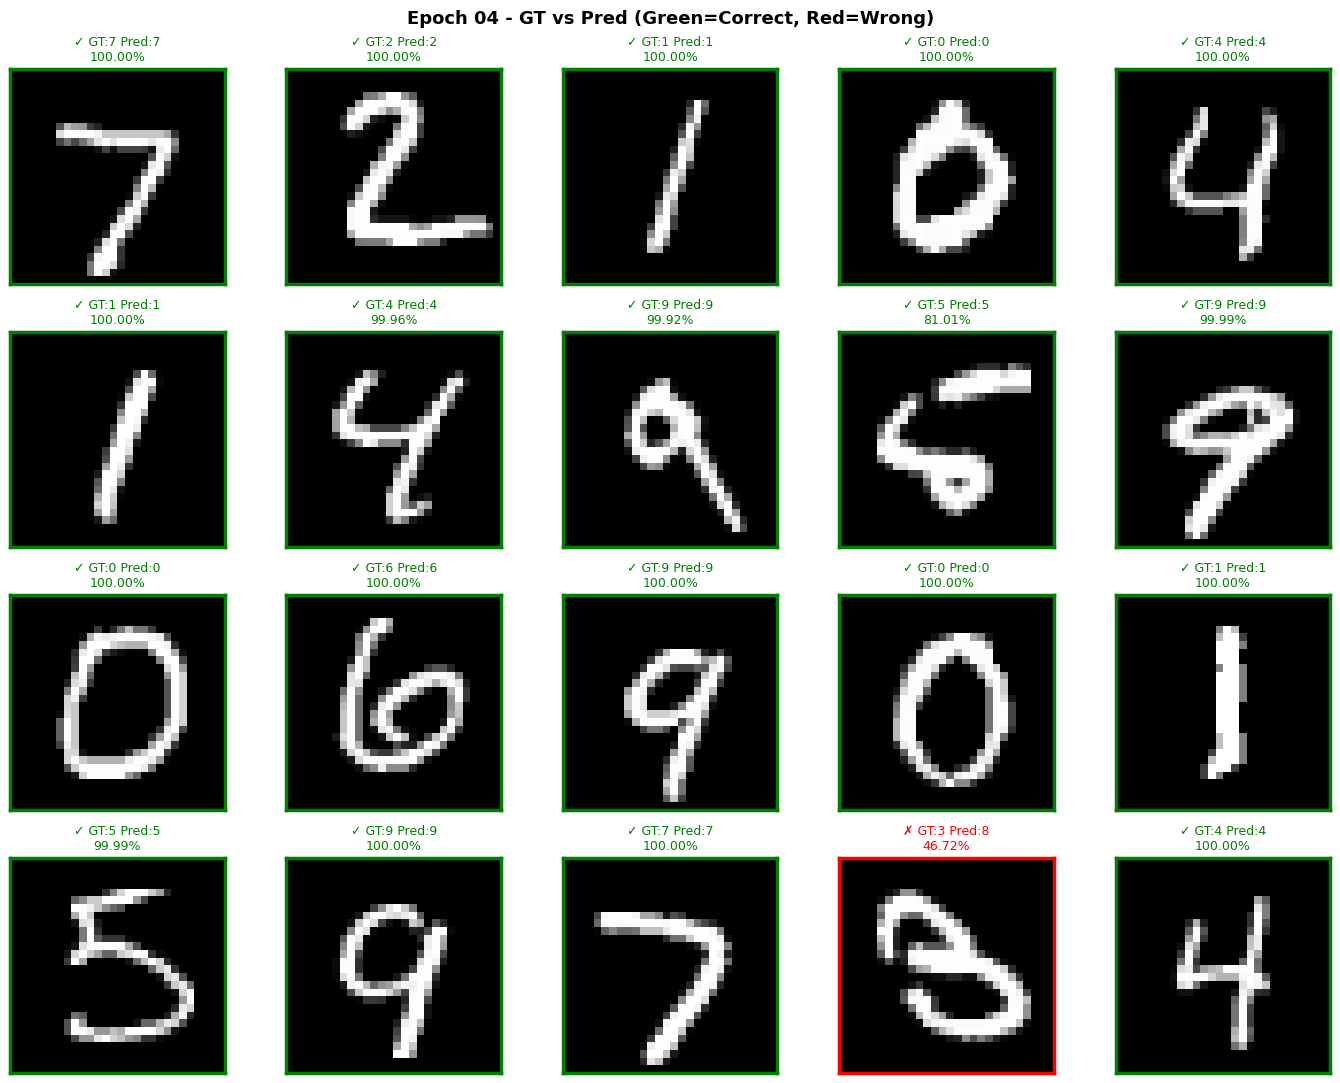

  Epoch 04/10 
  Train Loss: 0.0280 | Train Acc: 0.9913
  Val   Loss: 0.0220 | Val   Acc: 0.9922
  LR: 0.000500 | GradNorm: 0.6819 
  Epoch Time: 18.5s


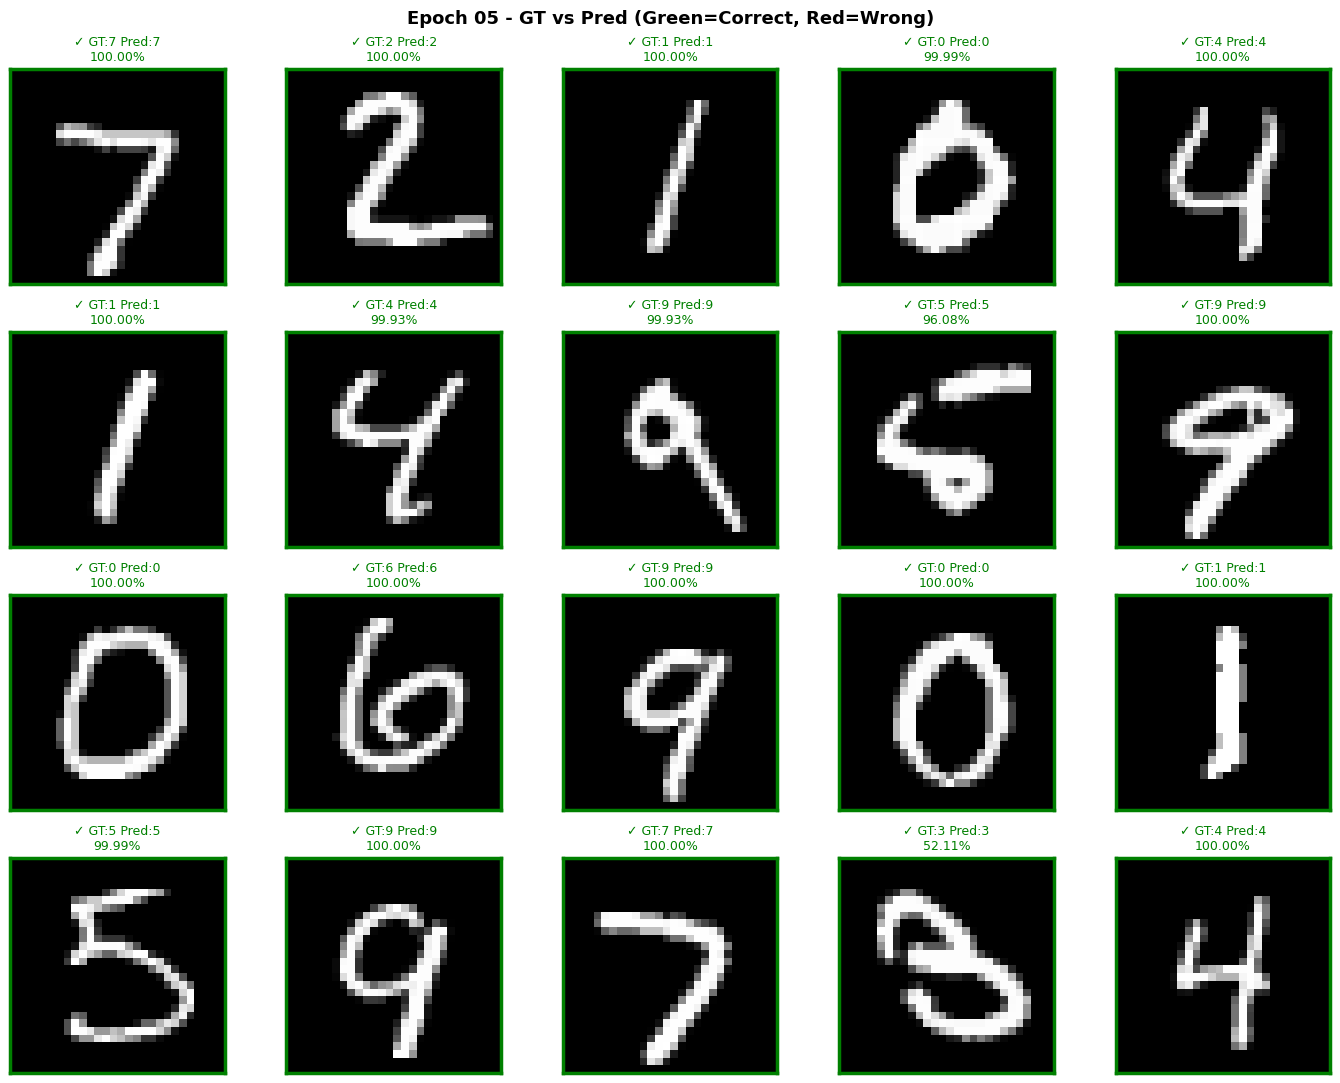

  Epoch 05/10 
  Train Loss: 0.0240 | Train Acc: 0.9927
  Val   Loss: 0.0246 | Val   Acc: 0.9919
  LR: 0.000500 | GradNorm: 0.6287 
  Epoch Time: 18.0s


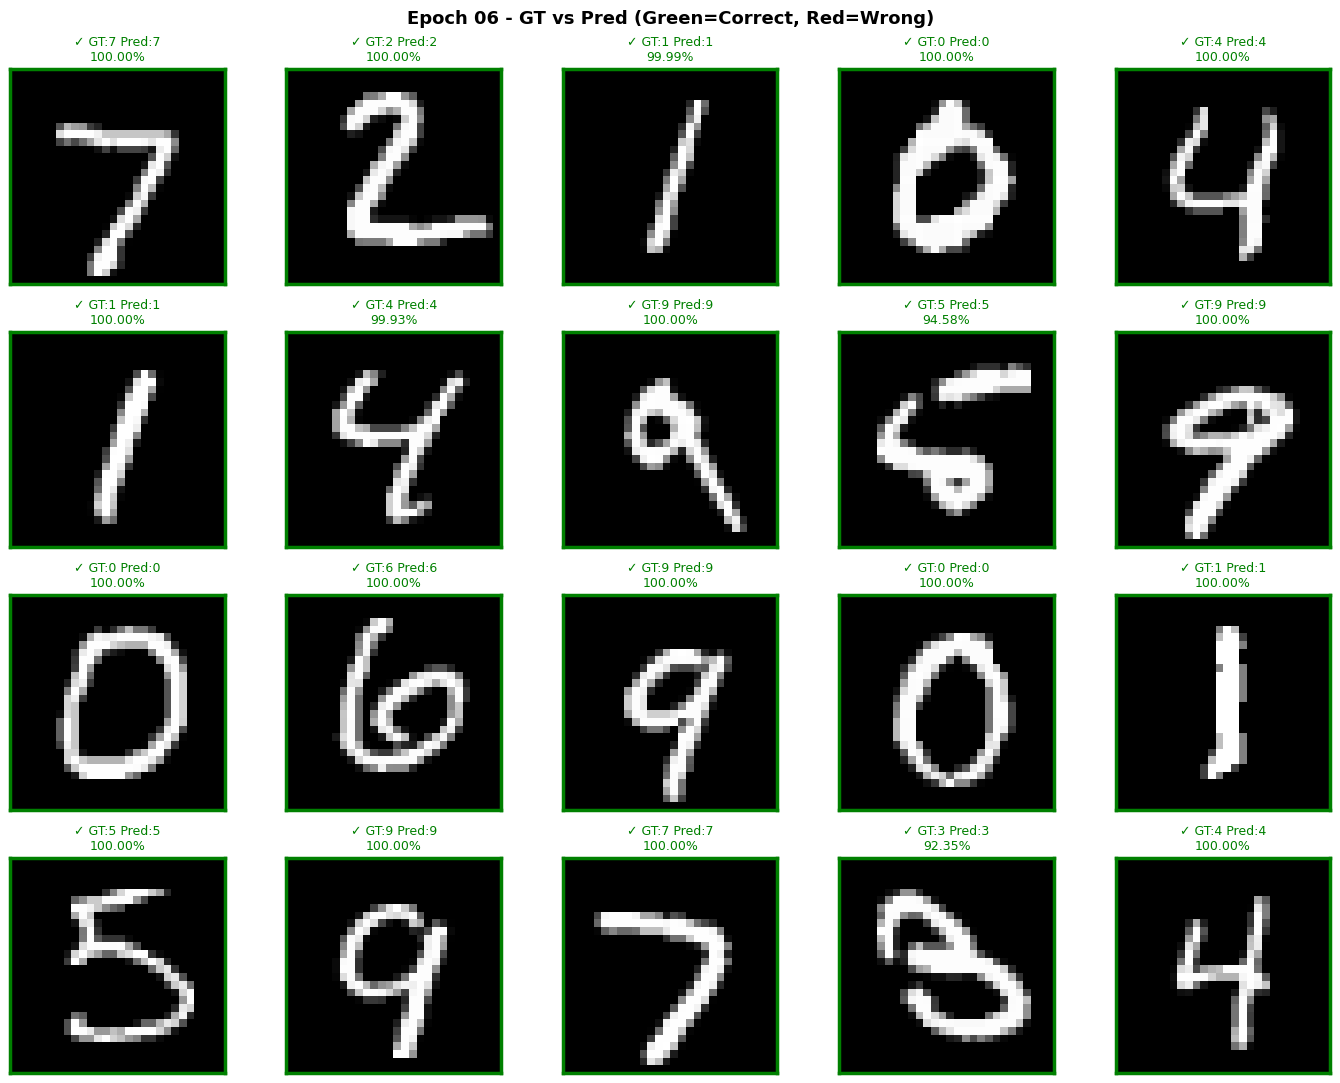

  Epoch 06/10 
  Train Loss: 0.0212 | Train Acc: 0.9928
  Val   Loss: 0.0254 | Val   Acc: 0.9918
  LR: 0.000250 | GradNorm: 0.5966 
  Epoch Time: 18.5s


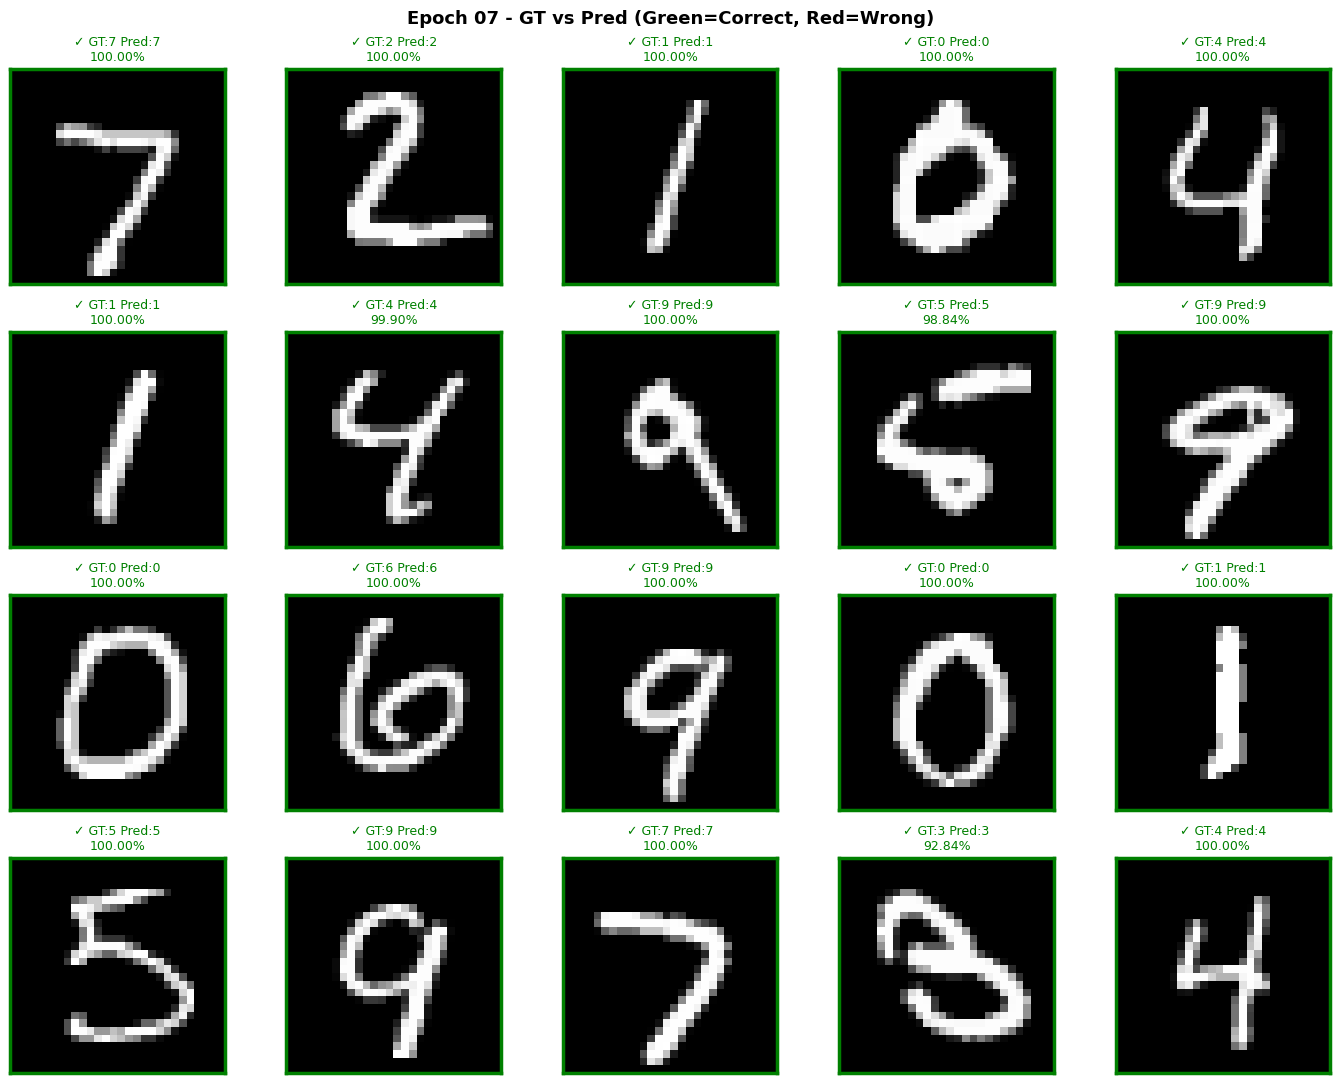

  Epoch 07/10 
  Train Loss: 0.0132 | Train Acc: 0.9959
  Val   Loss: 0.0204 | Val   Acc: 0.9930
  LR: 0.000250 | GradNorm: 0.4304 
  Epoch Time: 18.1s


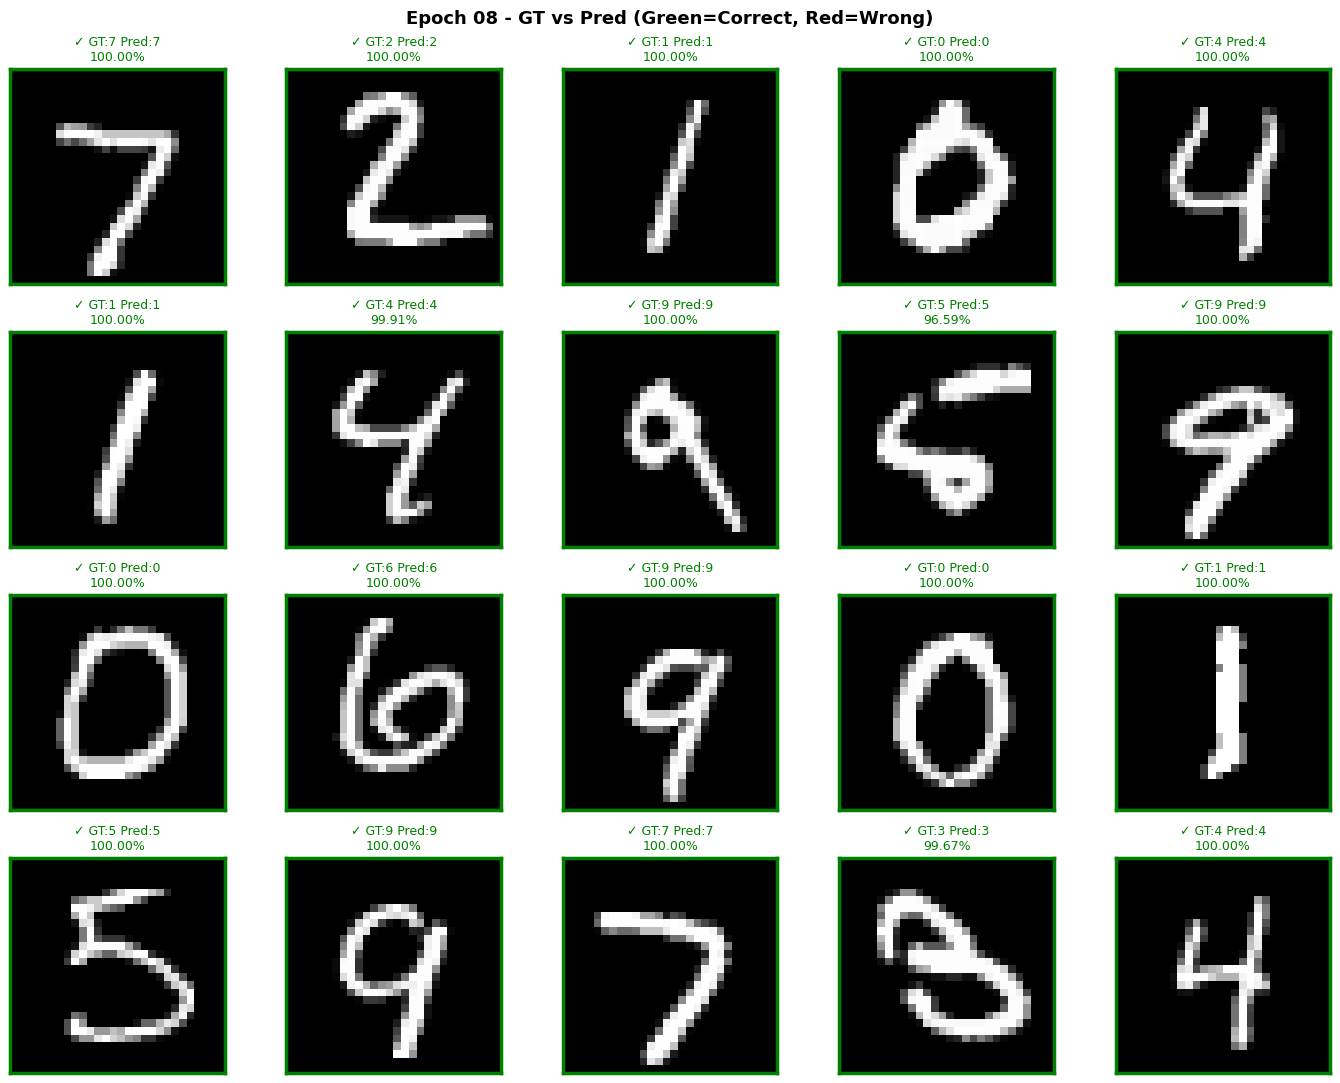

  Epoch 08/10 
  Train Loss: 0.0113 | Train Acc: 0.9963
  Val   Loss: 0.0230 | Val   Acc: 0.9922
  LR: 0.000250 | GradNorm: 0.4009 
  Epoch Time: 18.5s


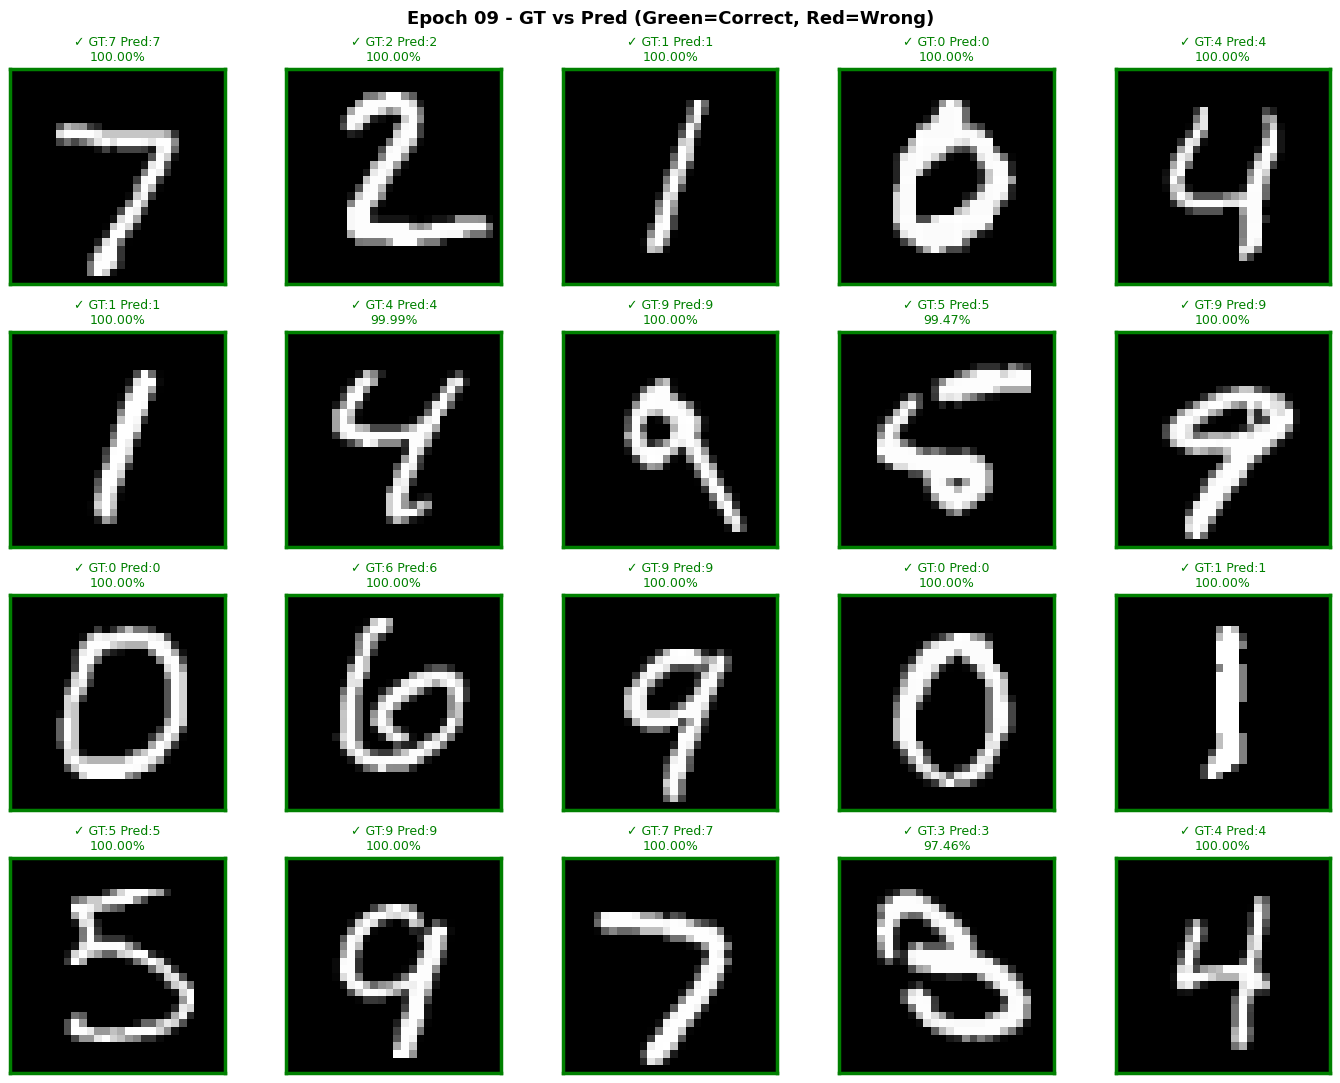

  Epoch 09/10 
  Train Loss: 0.0113 | Train Acc: 0.9964
  Val   Loss: 0.0219 | Val   Acc: 0.9932
  LR: 0.000125 | GradNorm: 0.4068 
  Epoch Time: 20.6s


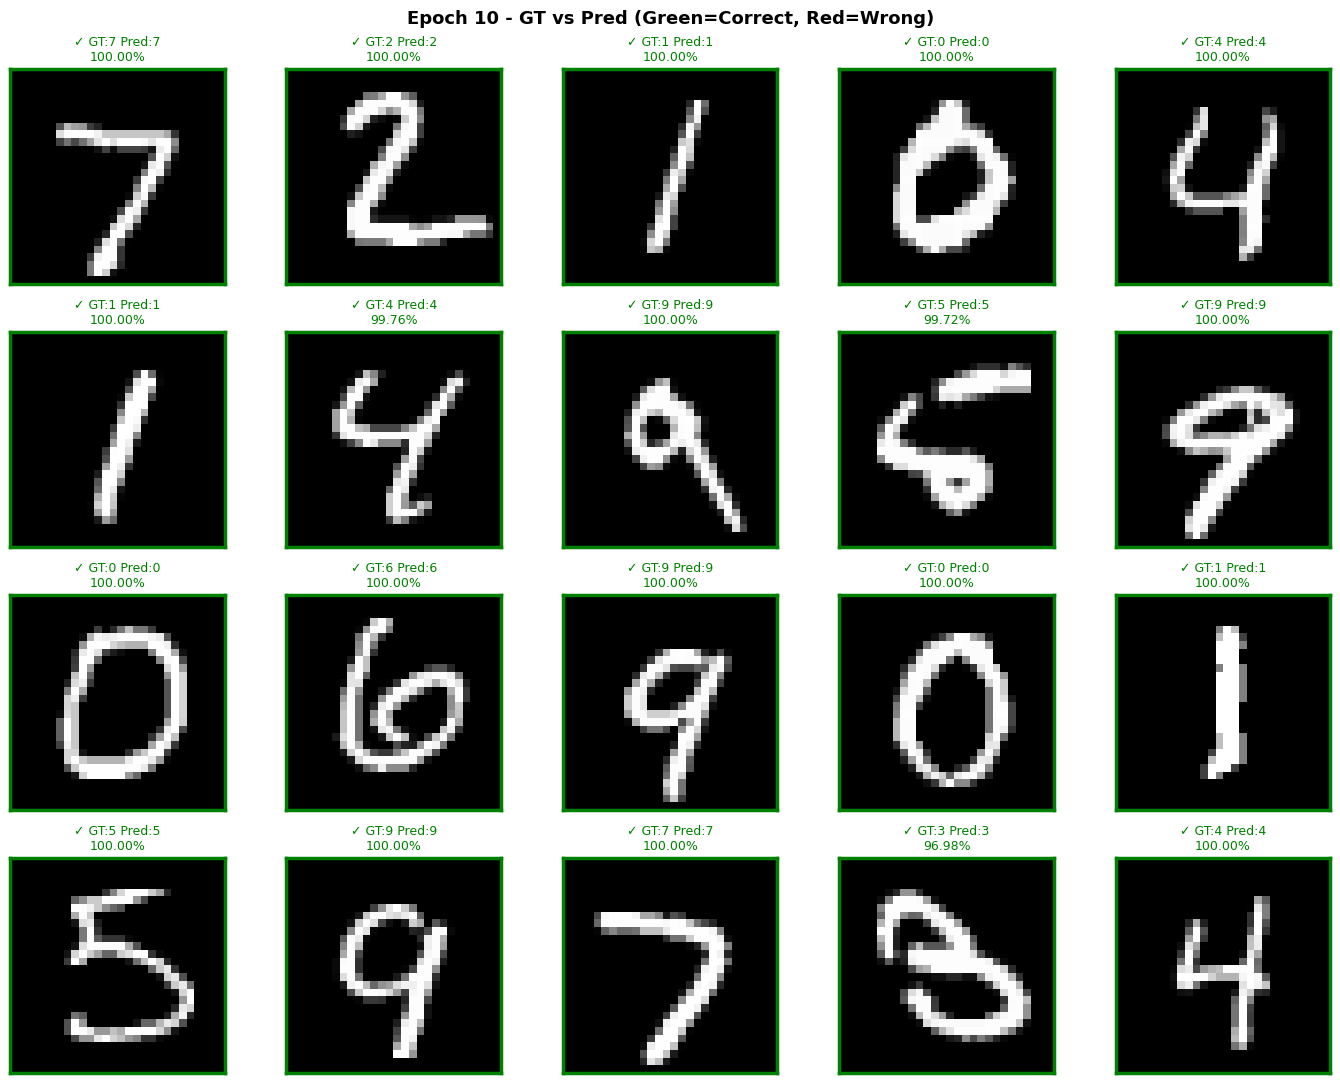

  Epoch 10/10 
  Train Loss: 0.0073 | Train Acc: 0.9979
  Val   Loss: 0.0190 | Val   Acc: 0.9935
  LR: 0.000125 | GradNorm: 0.2858 
  Epoch Time: 18.2s

Best Val Accuracy: 0.9935


In [9]:
# ============================================================
#   메인 학습 루프
# ============================================================
history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
    "lr":         [], "grad_norm": [],
    "epoch_time": []
}
best_val_acc = 0.0

test_imgs = next(iter(DataLoader(test_dataset, batch_size=20, shuffle=False)))[0].to(DEVICE)
test_labels = next(iter(DataLoader(test_dataset, batch_size=20, shuffle=False)))[1].to(DEVICE)

for epoch in range(1, config["epochs"] + 1):
    start = time.time()

    train_loss, train_acc, grad_norm = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, _, _, _       = evaluate(model, test_loader, criterion)
    scheduler.step()

    elapsed = time.time() - start
    current_lr = optimizer.param_groups[0]['lr']

    # 히스토리 저장
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)
    history["grad_norm"].append(grad_norm)
    history["epoch_time"].append(elapsed)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

    # ---- Epoch별 GT vs Pred 시각화 ----
    model.eval()
    with torch.no_grad():
        outputs = model(test_imgs)  # Normalize 없이 0~1 범위로 입력
        probs   = F.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        confs   = probs.max(dim=1).values.cpu().numpy()
    model.train()

    fig, axes = plt.subplots(4, 5, figsize=(14, 11))
    fig.suptitle(f'Epoch {epoch:02d} - GT vs Pred (Green=Correct, Red=Wrong)', fontsize=13, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        img    = test_imgs[i].squeeze().cpu().numpy()
        true_l = int(test_labels[i])
        pred_l = int(preds[i])
        conf   = float(confs[i])
        color  = 'green' if true_l == pred_l else 'red'
        mark   = '✓' if true_l == pred_l else '✗'
        ax.imshow(img, cmap='gray')
        ax.set_title(f'{mark} GT:{true_l} Pred:{pred_l}\n{conf:.2%}', color=color, fontsize=9)
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(2.5)
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.savefig(f'gt_vs_pred_epoch{epoch:02d}.png', dpi=100, bbox_inches='tight')
    plt.show(); plt.close()

    print("=" * 50)
    print(f"  Epoch {epoch:02d}/{config['epochs']} ")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print(f"  LR: {current_lr:.6f} | GradNorm: {grad_norm:.4f} ")
    print(f"  Epoch Time: {elapsed:.1f}s")
    print("=" * 50)

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

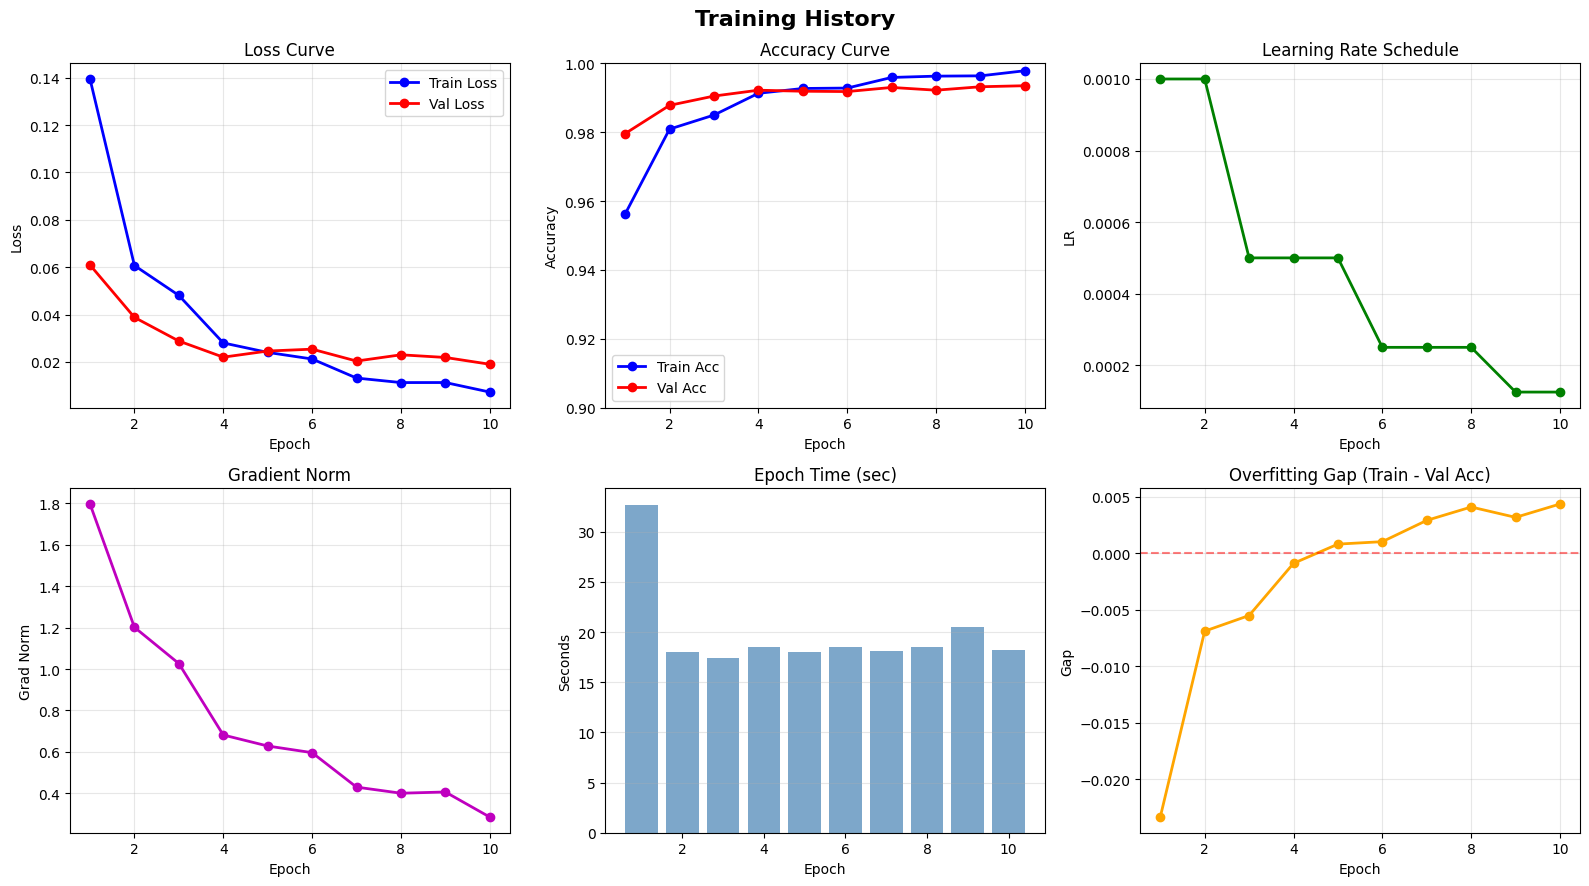

In [10]:
epochs_range = range(1, config["epochs"] + 1)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

# Loss 곡선
axes[0, 0].plot(epochs_range, history["train_loss"], 'b-o', label='Train Loss', linewidth=2)
axes[0, 0].plot(epochs_range, history["val_loss"],   'r-o', label='Val Loss',   linewidth=2)
axes[0, 0].set_title('Loss Curve'); axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# Accuracy 곡선
axes[0, 1].plot(epochs_range, history["train_acc"], 'b-o', label='Train Acc', linewidth=2)
axes[0, 1].plot(epochs_range, history["val_acc"],   'r-o', label='Val Acc',   linewidth=2)
axes[0, 1].set_title('Accuracy Curve'); axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.9, 1.0])

# Learning Rate
axes[0, 2].plot(epochs_range, history["lr"], 'g-o', linewidth=2)
axes[0, 2].set_title('Learning Rate Schedule'); axes[0, 2].set_xlabel('Epoch'); axes[0, 2].set_ylabel('LR')
axes[0, 2].grid(True, alpha=0.3)

# Gradient Norm
axes[1, 0].plot(epochs_range, history["grad_norm"], 'm-o', linewidth=2)
axes[1, 0].set_title('Gradient Norm'); axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Grad Norm')
axes[1, 0].grid(True, alpha=0.3)

# Epoch Time
axes[1, 1].bar(epochs_range, history["epoch_time"], color='steelblue', alpha=0.7)
axes[1, 1].set_title('Epoch Time (sec)'); axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Seconds')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Train vs Val Gap
gap = [t - v for t, v in zip(history["train_acc"], history["val_acc"])]
axes[1, 2].plot(epochs_range, gap, 'orange', marker='o', linewidth=2)
axes[1, 2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 2].set_title('Overfitting Gap (Train - Val Acc)'); axes[1, 2].set_xlabel('Epoch'); axes[1, 2].set_ylabel('Gap')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

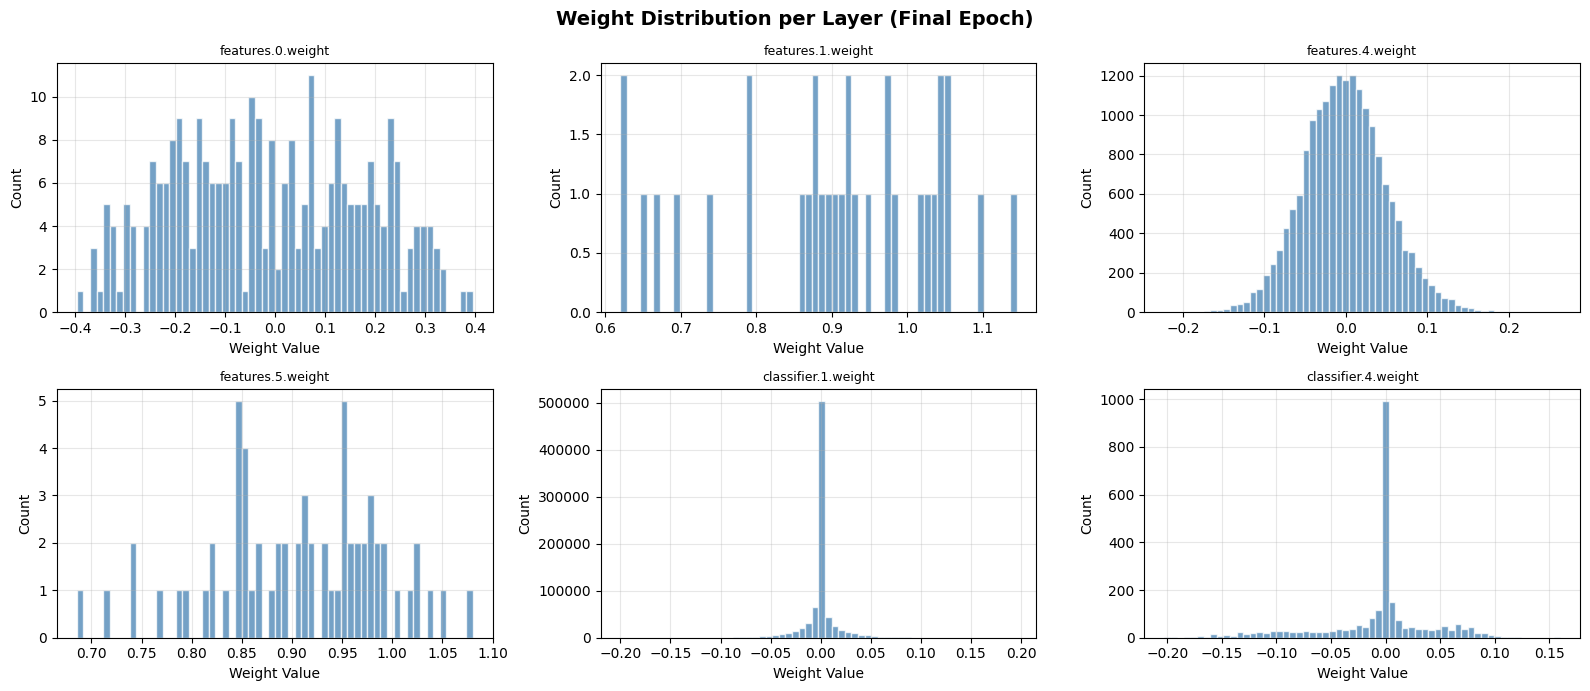

In [11]:
weight_layers = [(name, param.data.cpu().numpy().flatten())
                 for name, param in model.named_parameters()
                 if 'weight' in name and param.requires_grad]

n = len(weight_layers)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(16, 7))
fig.suptitle('Weight Distribution per Layer (Final Epoch)', fontsize=14, fontweight='bold')
axes = axes.flat

for ax, (name, weights) in zip(axes, weight_layers):
    ax.hist(weights, bins=60, color='steelblue', alpha=0.75, edgecolor='white')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)

for ax in list(axes)[len(weight_layers):]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('weight_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

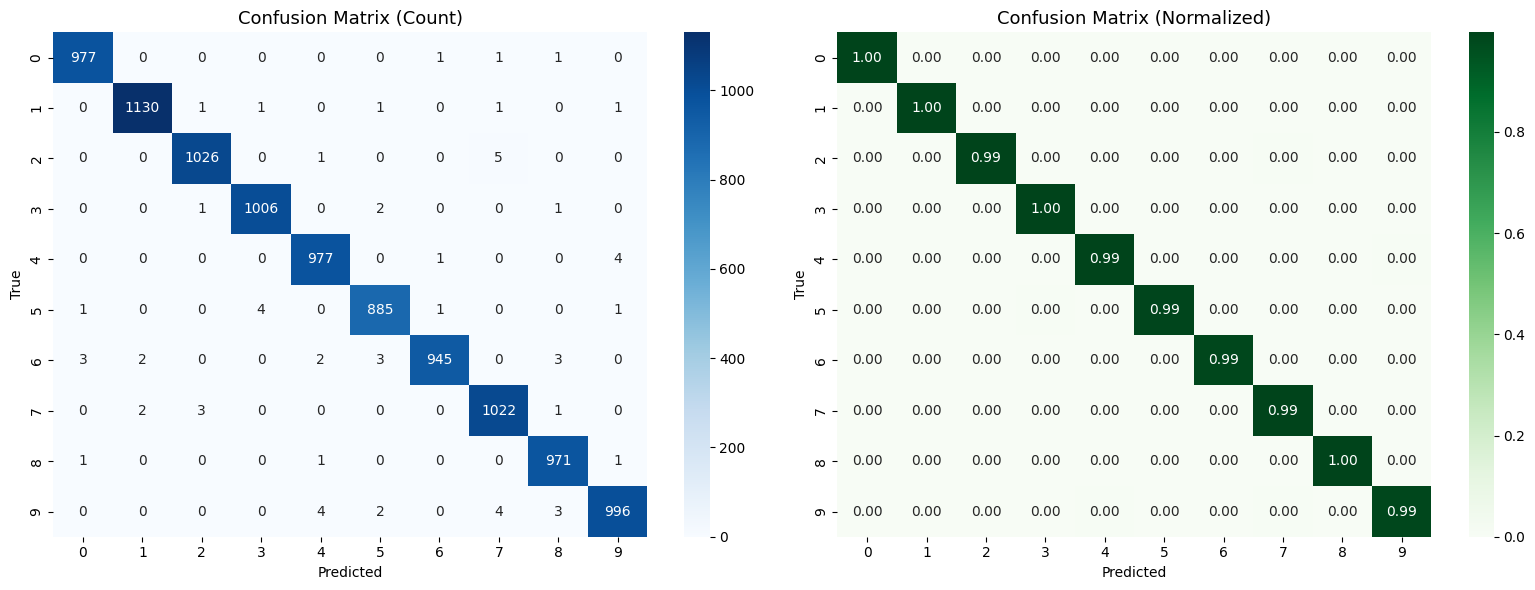

In [12]:
_, _, final_preds, final_labels, final_probs = evaluate(model, test_loader, criterion)
class_names = [str(i) for i in range(10)]

cm = confusion_matrix(final_labels, final_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 카운트
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Count)', fontsize=13)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# 정규화 (비율)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

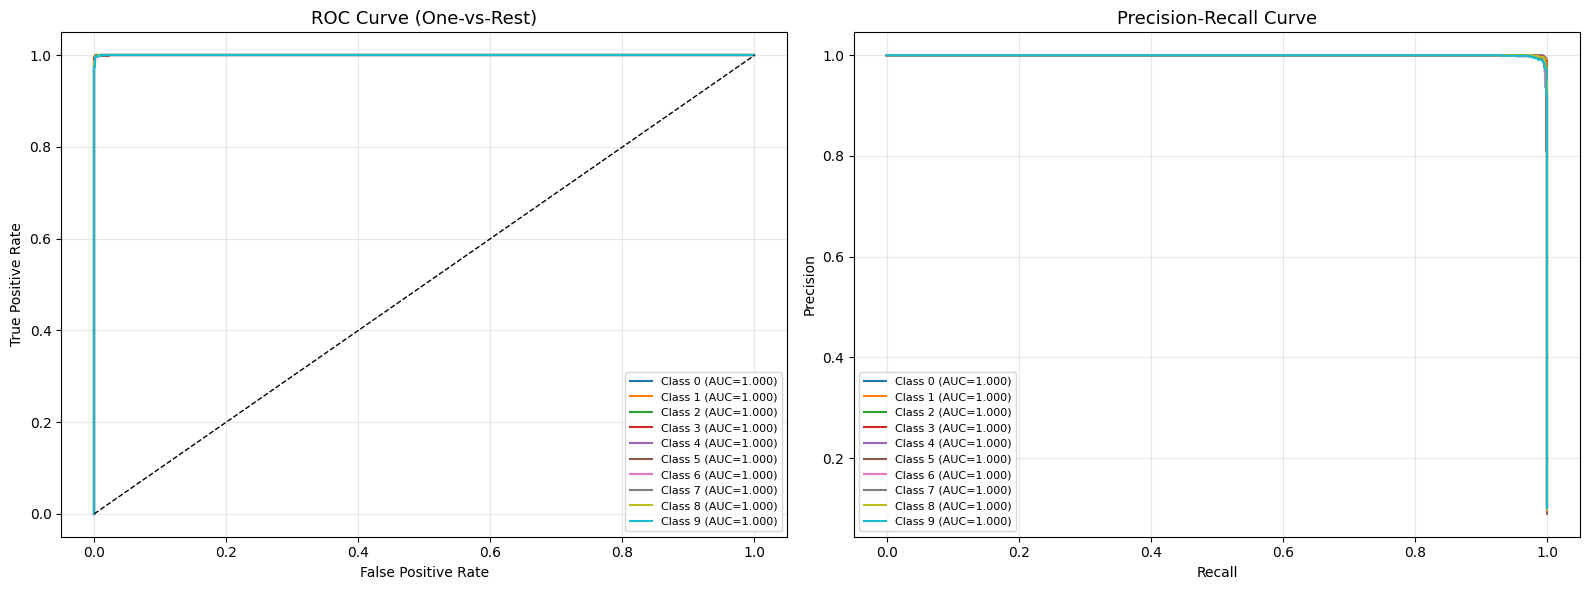

In [13]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(final_labels, classes=list(range(10)))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
for i in range(10):
    fpr, tpr, _ = roc_curve(y_bin[:, i], final_probs[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=colors[i], lw=1.5, label=f'Class {i} (AUC={roc_auc:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_title('ROC Curve (One-vs-Rest)', fontsize=13)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8, loc='lower right'); axes[0].grid(True, alpha=0.3)

# PR Curve
for i in range(10):
    prec, rec, _ = precision_recall_curve(y_bin[:, i], final_probs[:, i])
    pr_auc = auc(rec, prec)
    axes[1].plot(rec, prec, color=colors[i], lw=1.5, label=f'Class {i} (AUC={pr_auc:.3f})')
axes[1].set_title('Precision-Recall Curve', fontsize=13)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8, loc='lower left'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

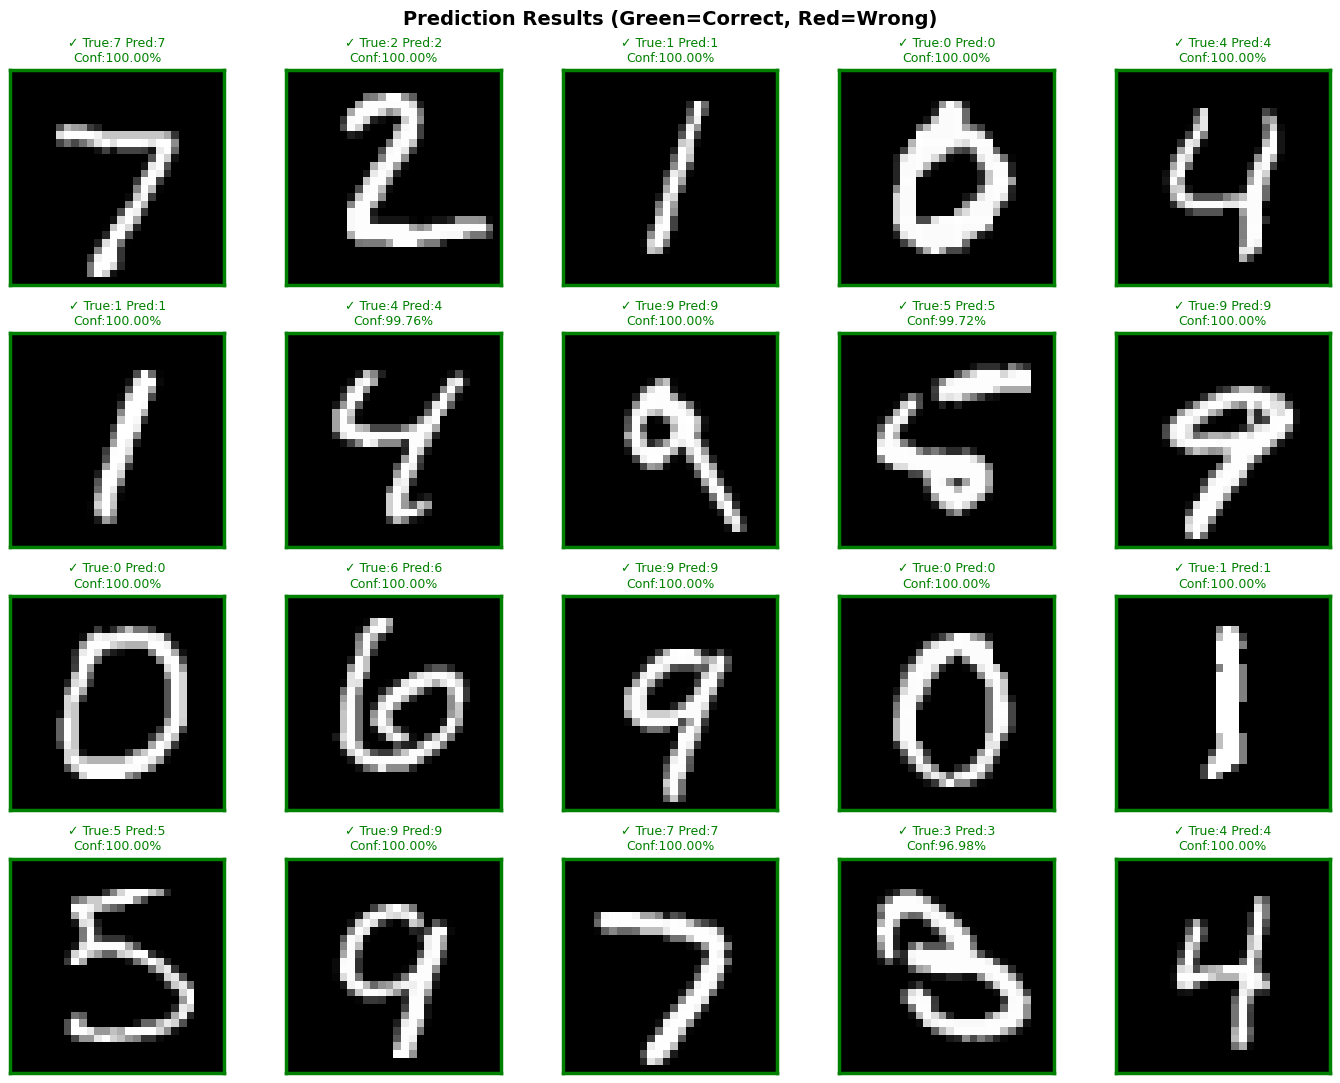

In [14]:
model.eval()
test_iter = iter(test_loader)
sample_imgs, sample_labels = next(test_iter)

with torch.no_grad():
    outputs = model(sample_imgs[:20].to(DEVICE))
    probs   = F.softmax(outputs, dim=1)
    preds   = outputs.argmax(dim=1).cpu().numpy()
    confs   = probs.max(dim=1).values.cpu().numpy()

fig, axes = plt.subplots(4, 5, figsize=(14, 11))
fig.suptitle('Prediction Results (Green=Correct, Red=Wrong)', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img = sample_imgs[i].squeeze().numpy()
    true_l = int(sample_labels[i])
    pred_l = int(preds[i])
    conf   = float(confs[i])
    correct = (true_l == pred_l)

    ax.imshow(img, cmap='gray')
    color = 'green' if correct else 'red'
    mark  = '✓' if correct else '✗'
    ax.set_title(f"{mark} True:{true_l} Pred:{pred_l}\nConf:{conf:.2%}",
                 color=color, fontsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2.5)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
print("=" * 50)
print("            FINAL SUMMARY")
print("=" * 50)
print(f"  Best Val Accuracy  : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"  Final Val Accuracy : {history['val_acc'][-1]:.4f}")
print(f"  Final Train Acc    : {history['train_acc'][-1]:.4f}")
print(f"  Final Val Loss     : {history['val_loss'][-1]:.4f}")
print(f"  Total Params       : {total_params:,}")
print(f"  Total Epoch Time   : {sum(history['epoch_time']):.1f}s")
print("=" * 50)

            FINAL SUMMARY
  Best Val Accuracy  : 0.9935 (99.35%)
  Final Val Accuracy : 0.9935
  Final Train Acc    : 0.9979
  Final Val Loss     : 0.0190
  Total Params       : 824,650
  Total Epoch Time   : 198.5s
